# Phase 4 — Modélisation

Ce notebook entraîne et évalue plusieurs modèles de classification sur le jeu de données enrichi issu de la Phase 3.  
Il couvre : la validation croisée stratifiée, la gestion du déséquilibre de classes via SMOTE dans un Pipeline imblearn, le suivi des expériences avec MLflow, et la sélection du meilleur modèle.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split

import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Model training")
mlflow.lightgbm.autolog(log_models=False)
mlflow.xgboost.autolog(log_models=False)

sns.set_theme(style="whitegrid")

## Chargement des données

In [4]:
DATA_PATH = "data/"

df_train = pd.read_parquet(DATA_PATH + "df_train_phase3.parquet")

print(f"Shape : {df_train.shape}")
df_train.head()

Shape : (307511, 210)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PREV_AMT_CREDIT_MEAN,INSTAL_COUNT,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DAYS_LATE_MEAN,CC_COUNT,CC_AMT_BALANCE_MEAN,CC_AMT_DRAWINGS_MEAN,POS_COUNT,POS_MONTHS_BALANCE_MEAN,POS_SK_DPD_MEAN
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,179055.00,19.0,11559.247105,-20.421053,22.0,26793.606316,3473.671875,19.0,-10.000000,0.0
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,484191.00,25.0,64754.586000,-7.160000,22.0,26793.606316,3473.671875,28.0,-43.785714,0.0
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,20106.00,3.0,7096.155000,-7.666667,22.0,26793.606316,3473.671875,4.0,-25.500000,0.0
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,291695.50,16.0,62947.088438,-19.375000,6.0,0.000000,0.000000,21.0,-9.619048,0.0
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,166638.75,66.0,12214.060227,-3.636364,22.0,26793.606316,3473.671875,66.0,-33.636364,0.0


## 4.1 — Déséquilibre des classes

/tmp/ipykernel_829362/1416911407.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=["#2ecc71", "#e74c3c"], ax=ax)


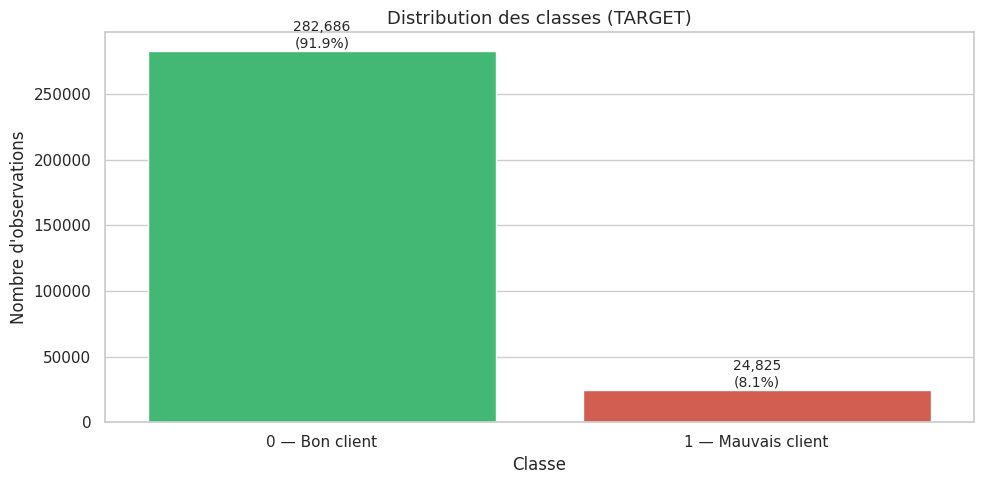

Classe 0 : 91.9% / Classe 1 : 8.1%


In [10]:
counts = df_train["TARGET"].value_counts().sort_index()
pcts = df_train["TARGET"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=counts.index, y=counts.values, palette=["#2ecc71", "#e74c3c"], ax=ax)
ax.set_title("Distribution des classes (TARGET)", fontsize=13)
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre d'observations")
ax.set_xticks([0, 1])
ax.set_xticklabels(["0 — Bon client", "1 — Mauvais client"])
for bar, (cls, n, p) in zip(ax.patches, zip(counts.index, counts.values, pcts.values)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{n:,}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Classe 0 : {pcts[0]:.1f}% / Classe 1 : {pcts[1]:.1f}%")

## 4.2 — Split stratifié

In [ ]:
X = df_train.drop(columns=["TARGET", "SK_ID_CURR"])
y = df_train["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shapes :")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

print("\nProportion de classe 1 (vérification stratification) :")
print(f"  y_train : {y_train.mean():.4f} ({y_train.mean() * 100:.2f}%)")
print(f"  y_test  : {y_test.mean():.4f} ({y_test.mean() * 100:.2f}%)")

## 4.3 — Gestion du déséquilibre

> **SMOTE dans le Pipeline** : SMOTE est appliqué pli par pli, à l'intérieur de la validation croisée, via un Pipeline imblearn. Il ne voit que le pli d'entraînement, jamais le pli de validation : pas de fuite. Lors de la prédiction, le pipeline ne ré-échantillonne pas X_test.

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

global_pct = y_train.mean() * 100

fold_stats = []
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    pct_train = y_train.iloc[train_idx].mean() * 100
    pct_val   = y_train.iloc[val_idx].mean()   * 100
    fold_stats.append({
        "Fold":                  fold_idx,
        "% défauts train":       round(pct_train, 2),
        "% défauts validation":  round(pct_val,   2),
    })

df_folds = pd.DataFrame(fold_stats).set_index("Fold")

# --- Graphique ---
fig, ax = plt.subplots(figsize=(10, 5))

bar_height = 0.35
folds = df_folds.index.tolist()
y_pos = np.arange(len(folds))

bars_train = ax.barh(y_pos + bar_height / 2, df_folds["% défauts train"],
                     height=bar_height, color="#2980b9", label="Train")
bars_val   = ax.barh(y_pos - bar_height / 2, df_folds["% défauts validation"],
                     height=bar_height, color="#e67e22", label="Validation")

ax.axvline(global_pct, color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"% réel dataset ({global_pct:.1f}%)")

for bar in bars_train:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}%", va="center", fontsize=9)
for bar in bars_val:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}%", va="center", fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"Fold {f}" for f in folds])
ax.set_xlabel("% classe 1 (défauts)")
ax.set_title("Distribution de la classe cible par fold (StratifiedKFold)")
ax.legend()
ax.set_xlim(0, max(df_folds.values.max() + 5, global_pct + 5))
plt.tight_layout()
plt.show()

# --- Tableau ---
display(df_folds)

## 5.1 Baseline — Logistic Regression

**Objectif** : Entraîner une Logistic Regression comme modèle de référence (baseline).  
Le déséquilibre est géré par SMOTE appliqué dans le Pipeline imblearn (pli par pli).  
Validation croisée StratifiedKFold (5 folds). Tracking MLflow complet.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import mlflow
import mlflow.sklearn

model_lr = LogisticRegression(solver="saga", max_iter=1000, random_state=42)
pipeline_lr = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   model_lr),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="logistic_regression_baseline"):
    mlflow.log_param("solver", "saga")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("smote", True)

    scores = cross_val_score(pipeline_lr, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

    auc_mean = scores.mean()
    auc_std  = scores.std()

    mlflow.log_metric("auc_roc_mean", auc_mean)
    mlflow.log_metric("auc_roc_std",  auc_std)

    print(f"AUC-ROC par fold : {[round(s, 4) for s in scores]}")
    print(f"AUC-ROC moyen    : {auc_mean:.4f} ± {auc_std:.4f}")

## 5.2 Random Forest

**Objectif** : Entraîner un Random Forest.  
Comparaison avec la baseline Logistic Regression.  
Validation croisée StratifiedKFold (5 folds). Tracking MLflow complet.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
pipeline_rf = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   model_rf),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="random_forest_baseline"):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("smote", True)

    scores = cross_val_score(pipeline_rf, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

    auc_mean = scores.mean()
    auc_std  = scores.std()

    mlflow.log_metric("auc_roc_mean", auc_mean)
    mlflow.log_metric("auc_roc_std",  auc_std)

    print(f"AUC-ROC par fold : {[round(s, 4) for s in scores]}")
    print(f"AUC-ROC moyen    : {auc_mean:.4f} ± {auc_std:.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score

# Entraînement sur l'ensemble d'entraînement complet
pipeline_rf.fit(X_train, y_train)

# Évaluation sur le test set (jamais rééchantillonné)
y_proba_test = pipeline_rf.predict_proba(X_test)[:, 1]
auc_roc_test = roc_auc_score(y_test, y_proba_test)

print(f"AUC-ROC test : {auc_roc_test:.4f}")

# Log dans le run MLflow "random_forest_baseline" existant
runs = mlflow.search_runs(
    filter_string='tags.mlflow.runName = "random_forest_baseline"',
    order_by=["start_time DESC"]
)
run_id = runs.iloc[0]["run_id"]

with mlflow.start_run(run_id=run_id):
    mlflow.log_metric("auc_roc_test", auc_roc_test)

## 5.3 LightGBM

**Objectif** : Entraîner un LightGBM comme modèle plus puissant.  
Validation croisée StratifiedKFold (5 folds). Évaluation sur le test set. Tracking MLflow complet.

In [ ]:
import re
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# LightGBM rejette les caractères spéciaux dans les noms de colonnes
def clean_col_names(df):
    df = df.copy()
    df.columns = [re.sub(r"[^A-Za-z0-9_]", "_", c) for c in df.columns]
    return df

X_train_lgbm = clean_col_names(X_train)
X_test_lgbm  = clean_col_names(X_test)

mlflow.set_experiment("Model training")

model_lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
pipeline_lgbm = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   model_lgbm),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="lgbm_baseline"):
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("smote", True)

    scores = cross_val_score(
        pipeline_lgbm, X_train_lgbm, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
    )
    auc_roc_mean = scores.mean()
    auc_roc_std  = scores.std()

    mlflow.log_metric("auc_roc_mean", auc_roc_mean)
    mlflow.log_metric("auc_roc_std",  auc_roc_std)

    pipeline_lgbm.fit(X_train_lgbm, y_train)
    y_proba_test = pipeline_lgbm.predict_proba(X_test_lgbm)[:, 1]
    auc_roc_test = roc_auc_score(y_test, y_proba_test)

    mlflow.log_metric("auc_roc_test", auc_roc_test)

print(f"AUC-ROC par fold : {[round(s, 4) for s in scores]}")
print(f"AUC-ROC moyen    : {auc_roc_mean:.4f} ± {auc_roc_std:.4f}")
print(f"AUC-ROC test     : {auc_roc_test:.4f}")

## 5.4 XGBoost

**Objectif** : Entraîner un XGBoost.  
Le déséquilibre est géré par SMOTE appliqué dans le Pipeline imblearn (pli par pli).  
Validation croisée StratifiedKFold (5 folds). Évaluation sur le test set. Tracking MLflow complet.

In [ ]:
import re
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost rejette les caractères spéciaux dans les noms de colonnes
def clean_col_names(df):
    df = df.copy()
    df.columns = [re.sub(r"[^A-Za-z0-9_]", "_", c) for c in df.columns]
    return df

X_train_xgb = clean_col_names(X_train)
X_test_xgb  = clean_col_names(X_test)

mlflow.set_experiment("Model training")

model_xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric="auc"
)
pipeline_xgb = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   model_xgb),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="xgboost_baseline"):
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("smote", True)

    scores = cross_val_score(
        pipeline_xgb, X_train_xgb, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
    )
    auc_roc_mean = scores.mean()
    auc_roc_std  = scores.std()

    mlflow.log_metric("auc_roc_mean", auc_roc_mean)
    mlflow.log_metric("auc_roc_std",  auc_roc_std)

    pipeline_xgb.fit(X_train_xgb, y_train)
    y_proba_test = pipeline_xgb.predict_proba(X_test_xgb)[:, 1]
    auc_roc_test = roc_auc_score(y_test, y_proba_test)

    mlflow.log_metric("auc_roc_test", auc_roc_test)

print(f"AUC-ROC par fold : {[round(s, 4) for s in scores]}")
print(f"AUC-ROC moyen    : {auc_roc_mean:.4f} ± {auc_roc_std:.4f}")
print(f"AUC-ROC test     : {auc_roc_test:.4f}")

## 6.7 — Tableau comparatif des métriques

**Objectif** : comparer LightGBM et XGBoost sur les métriques clés au seuil optimal de 0.09.

Métriques retenues :
- **AUC-ROC** : capacité discriminante globale
- **Recall classe 1** : taux de détection des clients à risque
- **F1-score classe 1** : équilibre précision / recall
- **Coût métier** : FN × 10 + FP × 1 (un faux négatif coûte 10× plus qu'un faux positif)

In [ ]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score

THRESHOLD = 0.09

def compute_metrics(model, X_test_model, y_test, model_name):
    y_proba = model.predict_proba(X_test_model)[:, 1]
    y_pred  = (y_proba >= THRESHOLD).astype(int)

    fn = int(((y_test == 1) & (y_pred == 0)).sum())
    fp = int(((y_test == 0) & (y_pred == 1)).sum())
    
    auc     = round(roc_auc_score(y_test, y_proba), 4)
    recall  = round(recall_score(y_test, y_pred), 4)
    f1      = round(f1_score(y_test, y_pred), 4)
    cout    = fn * 10 + fp * 1

    # ✅ Logger dans MLflow
    with mlflow.start_run(run_name=f"{model_name}_threshold_009"):
        mlflow.log_param("threshold", THRESHOLD)
        mlflow.log_metric("auc_roc", auc)
        mlflow.log_metric("recall_classe1", recall)
        mlflow.log_metric("f1_classe1", f1)
        mlflow.log_metric("business_cost", cout)

    return {
        "Modèle":           model_name,
        "AUC-ROC":          auc,
        "Recall (cl. 1)":   recall,
        "F1-score (cl. 1)": f1,
        "Coût métier":      cout,
    }

rows = [
    compute_metrics(model_lgbm, X_test_lgbm, y_test, "LightGBM"),
    compute_metrics(model_xgb,  X_test_xgb,  y_test, "XGBoost"),
]

df_metrics = pd.DataFrame(rows).set_index("Modèle")
df_metrics.style.highlight_min(subset=["Coût métier"], color="#f9c7c7") \
               .highlight_max(subset=["AUC-ROC", "Recall (cl. 1)", "F1-score (cl. 1)"], color="#c7f2c7") \
               .format({"Coût métier": "{:,}"})

In [16]:
import mlflow.lightgbm

# Enregistrer le modèle LightGBM dans le registry
with mlflow.start_run(run_name="lgbm_baseline_registered"):
    mlflow.lightgbm.log_model(
        lgb_model=model_lgbm,
        artifact_path="lgbm_model",
        registered_model_name="credit_scoring_lgbm"
    )
    mlflow.log_metric("auc_roc_test", 0.7674)

2026/06/05 10:05:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 10:05:07 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'credit_scoring_lgbm'.
Created version '1' of model 'credit_scoring_lgbm'.


## 7.1 — Fonction de coût métier

**Objectif** : Trouver le seuil de décision qui minimise le coût métier.

Modèle de coût :
- **Faux Négatif (FN)** : un client défaillant classé solvable → coût **10**
- **Faux Positif (FP)** : un client solvable classé défaillant → coût **1**

On balaye tous les seuils de 0.01 à 0.99 et on retient celui qui minimise `FN × 10 + FP × 1`.

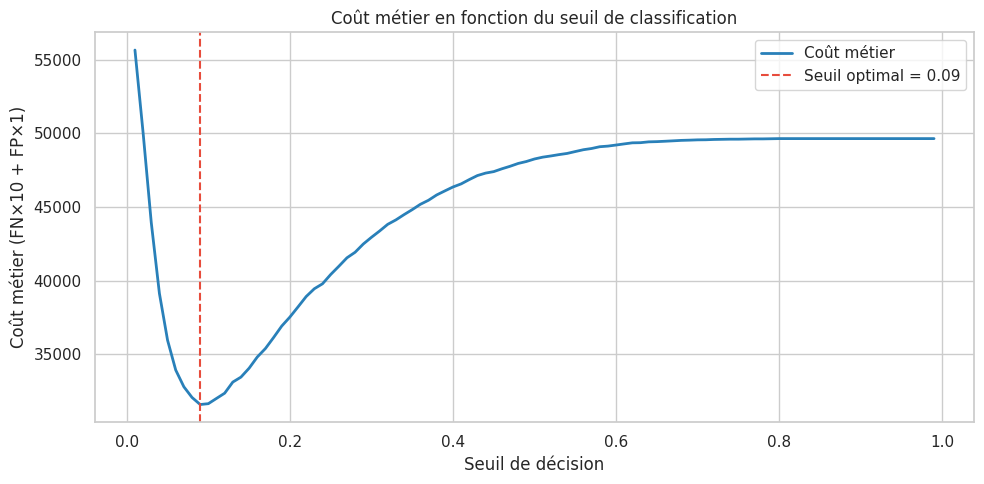

Seuil optimal      : 0.09
Coût minimal       : 31,574
Coût au seuil 0.50 : 48,265


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import mlflow

# 1. Fonction de coût métier
def business_cost(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return fn * 10 + fp * 1

# 2. Probabilités sur le test set
y_proba_test = model_lgbm.predict_proba(X_test_lgbm)[:, 1]

# 3. Balayage des seuils
thresholds = np.arange(0.01, 1.00, 0.01)
costs = [business_cost(y_test, y_proba_test, t) for t in thresholds]

# 4. Seuil optimal
optimal_idx = int(np.argmin(costs))
optimal_threshold = thresholds[optimal_idx]
min_cost = costs[optimal_idx]
cost_at_05 = business_cost(y_test, y_proba_test, 0.5)

# 5. Courbe coût vs seuil
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, costs, color="#2980b9", linewidth=2, label="Coût métier")
ax.axvline(optimal_threshold, color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Seuil optimal = {optimal_threshold:.2f}")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Coût métier (FN×10 + FP×1)")
ax.set_title("Coût métier en fonction du seuil de classification")
ax.legend()
plt.tight_layout()
plt.show()

# 6. Résumé
print(f"Seuil optimal      : {optimal_threshold:.2f}")
print(f"Coût minimal       : {min_cost:,}")
print(f"Coût au seuil 0.50 : {cost_at_05:,}")

# 7. Log MLflow
mlflow.set_experiment("Model training")
with mlflow.start_run(run_name="lgbm_threshold_optimization"):
    mlflow.log_metric("optimal_threshold",    round(float(optimal_threshold), 4))
    mlflow.log_metric("min_business_cost",    int(min_cost))
    mlflow.log_metric("business_cost_at_05",  int(cost_at_05))

## 7.2 — Optimisation Optuna LightGBM

**Objectif** : Trouver les hyperparamètres qui maximisent l'AUC-ROC test via une recherche bayésienne (50 trials).

Paramètres optimisés : `n_estimators`, `learning_rate`, `max_depth`, `num_leaves`, `min_child_samples`.

In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import mlflow

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Fonction objective — SMOTE dans le pipeline (pas de fuite)
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "random_state":      42,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf",   LGBMClassifier(**params)),
    ])
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # augmentable
    scores = cross_val_score(pipeline, X_train_lgbm, y_train,
                             cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# Étude Optuna — 20 trials (augmentable pour une recherche plus fine)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

# Meilleurs paramètres
best_params = study.best_params
best_auc_cv = study.best_value
print("Meilleurs paramètres :")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nMeilleur AUC-ROC CV : {best_auc_cv:.4f}")

# Réentraînement sur l'ensemble complet
pipeline_optuna = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   LGBMClassifier(**best_params, random_state=42, n_jobs=-1, verbose=-1)),
])
pipeline_optuna.fit(X_train_lgbm, y_train)

# Évaluation test (jamais rééchantillonné)
y_proba_optuna = pipeline_optuna.predict_proba(X_test_lgbm)[:, 1]
auc_roc_test = roc_auc_score(y_test, y_proba_optuna)

# Log MLflow
mlflow.set_experiment("Model training")
with mlflow.start_run(run_name="lgbm_optuna"):
    for k, v in best_params.items():
        mlflow.log_param(k, v)
    mlflow.log_metric("auc_roc_mean", round(best_auc_cv, 4))
    mlflow.log_metric("auc_roc_test", round(auc_roc_test, 4))

print(f"\nBaseline AUC test : cf. cellule lgbm_baseline")
print(f"Optuna  AUC test  : {auc_roc_test:.4f}")